# HUST Battery Dataset
## Chemistry: LFP Li-ion
### Institution: Huazhong University of Science and Technology
#### Objective: SOC Estimation using LSTM and GRU

### importing libraries and loading the dataset

In [2]:
#importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import zipfile
import requests

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout

In [6]:
import zipfile

zip_path = r"C:\Users\shrij\Downloads\our_data.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(r"C:\HUST")

print("Extraction Complete")

Extraction Complete


In [7]:
import os

for root, dirs, files in os.walk(r"C:\HUST"):
    for file in files:
        print(os.path.join(root, file))

C:\HUST\our_data\1-1.pkl
C:\HUST\our_data\1-2.pkl
C:\HUST\our_data\1-3.pkl
C:\HUST\our_data\1-4.pkl
C:\HUST\our_data\1-5.pkl
C:\HUST\our_data\1-6.pkl
C:\HUST\our_data\1-7.pkl
C:\HUST\our_data\1-8.pkl
C:\HUST\our_data\10-1.pkl
C:\HUST\our_data\10-2.pkl
C:\HUST\our_data\10-3.pkl
C:\HUST\our_data\10-4.pkl
C:\HUST\our_data\10-5.pkl
C:\HUST\our_data\10-6.pkl
C:\HUST\our_data\10-7.pkl
C:\HUST\our_data\10-8.pkl
C:\HUST\our_data\2-2.pkl
C:\HUST\our_data\2-3.pkl
C:\HUST\our_data\2-4.pkl
C:\HUST\our_data\2-5.pkl
C:\HUST\our_data\2-6.pkl
C:\HUST\our_data\2-7.pkl
C:\HUST\our_data\2-8.pkl
C:\HUST\our_data\3-1.pkl
C:\HUST\our_data\3-2.pkl
C:\HUST\our_data\3-3.pkl
C:\HUST\our_data\3-4.pkl
C:\HUST\our_data\3-5.pkl
C:\HUST\our_data\3-6.pkl
C:\HUST\our_data\3-7.pkl
C:\HUST\our_data\3-8.pkl
C:\HUST\our_data\4-1.pkl
C:\HUST\our_data\4-2.pkl
C:\HUST\our_data\4-3.pkl
C:\HUST\our_data\4-4.pkl
C:\HUST\our_data\4-5.pkl
C:\HUST\our_data\4-6.pkl
C:\HUST\our_data\4-7.pkl
C:\HUST\our_data\4-8.pkl
C:\HUST\our_data\

In [16]:
import pickle

with open(r"C:\HUST\our_data\1-1.pkl", "rb") as f:
    data = pickle.load(f)

battery = data['1-1']

print("TYPE =", type(battery))

if isinstance(battery, dict):
    print("KEYS =", battery.keys())

elif hasattr(battery, "columns"):
    print("SHAPE =", battery.shape)
    print("COLUMNS =", battery.columns)
    print(battery.head())

else:
    try:
        print("SHAPE =", battery.shape)
    except:
        pass

    print(battery)

TYPE = <class 'dict'>
KEYS = dict_keys(['rul', 'dq', 'data'])


In [17]:
print(type(battery['rul']))
print(type(battery['dq']))
print(type(battery['data']))

<class 'dict'>
<class 'dict'>
<class 'dict'>


In [18]:
print(battery['rul'])

print("\nDQ:")
print(battery['dq'])

print("\nDATA TYPE:")
print(type(battery['data']))

{1: 1504, 2: 1503, 3: 1502, 4: 1501, 5: 1500, 6: 1499, 7: 1498, 8: 1497, 9: 1496, 10: 1495, 11: 1494, 12: 1493, 13: 1492, 14: 1491, 15: 1490, 16: 1489, 17: 1488, 18: 1487, 19: 1486, 20: 1485, 21: 1484, 22: 1483, 23: 1482, 24: 1481, 25: 1480, 26: 1479, 27: 1478, 28: 1477, 29: 1476, 30: 1475, 31: 1474, 32: 1473, 33: 1472, 34: 1471, 35: 1470, 36: 1469, 37: 1468, 38: 1467, 39: 1466, 40: 1465, 41: 1464, 42: 1463, 43: 1462, 44: 1461, 45: 1460, 46: 1459, 47: 1458, 48: 1457, 49: 1456, 50: 1455, 51: 1454, 52: 1453, 53: 1452, 54: 1451, 55: 1450, 56: 1449, 57: 1448, 58: 1447, 59: 1446, 60: 1445, 61: 1444, 62: 1443, 63: 1442, 64: 1441, 65: 1440, 66: 1439, 67: 1438, 68: 1437, 69: 1436, 70: 1435, 71: 1434, 72: 1433, 73: 1432, 74: 1431, 75: 1430, 76: 1429, 77: 1428, 78: 1427, 79: 1426, 80: 1425, 81: 1424, 82: 1423, 83: 1422, 84: 1421, 85: 1420, 86: 1419, 87: 1418, 88: 1417, 89: 1416, 90: 1415, 91: 1414, 92: 1413, 93: 1412, 94: 1411, 95: 1410, 96: 1409, 97: 1408, 98: 1407, 99: 1406, 100: 1405, 101: 14

In [19]:
data_part = battery['data']

print(type(data_part))

if isinstance(data_part, dict):
    print(data_part.keys())

elif hasattr(data_part, 'columns'):
    print(data_part.columns)
    print(data_part.head())

else:
    print(data_part)

<class 'dict'>
dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 21

In [20]:
data_part = battery['data']

print(type(data_part[1]))
print("\n")

cycle1 = data_part[1]

if isinstance(cycle1, dict):
    print(cycle1.keys())

elif hasattr(cycle1, "columns"):
    print(cycle1.columns)
    print(cycle1.head())

else:
    print(cycle1)

<class 'pandas.core.frame.DataFrame'>


Index(['Status', 'Cycle number', 'Current (mA)', 'Voltage (V)',
       'Capacity (mAh)', 'Time (s)'],
      dtype='object')
                    Status  Cycle number  Current (mA)  Voltage (V)  \
0  Constant current charge             1       5498.13       2.7731   
1  Constant current charge             1       5498.51       2.9811   
2  Constant current charge             1       5498.51       3.0912   
3  Constant current charge             1       5498.51       3.1606   
4  Constant current charge             1       5498.13       3.2118   

   Capacity (mAh)  Time (s)  
0        0.000000         0  
1        7.636397         4  
2       15.273111         9  
3       22.909931        14  
4       30.546642        19  


# HUST Battery Dataset

### Chemistry: LFP (Lithium Iron Phosphate)

**Institution:** Huazhong University of Science and Technology (HUST)

**Objective:** State of Charge (SOC) Estimation using LSTM and GRU Networks

---

## Dataset Exploration and Preprocessing

### Steps Performed

1. Downloaded and extracted the HUST battery dataset.
2. Inspected the dataset structure stored in `.pkl` files.
3. Loaded battery file `1-1.pkl` using Python pickle.
4. Identified the dataset hierarchy consisting of:
   - Remaining Useful Life (RUL)
   - Capacity Degradation (DQ)
   - Cycle-wise Battery Data
5. Extracted cycle-wise measurements from the `data` dictionary.
6. Identified available features:
   - Current (mA)
   - Voltage (V)
   - Capacity (mAh)
   - Time (s)
7. Verified that each cycle is stored as a Pandas DataFrame.
8. Planned SOC calculation using capacity information.
9. Prepared cycle-wise data for merging into a single dataset for deep learning.

---

## Available Features

| Feature | Description |
|----------|-------------|
| Voltage (V) | Battery terminal voltage |
| Current (mA) | Charging/Discharging current |
| Capacity (mAh) | Measured battery capacity |
| Time (s) | Time elapsed during cycle |

### Target Variable

**SOC (State of Charge)**

SOC will be computed using capacity information and used as the prediction target for LSTM and GRU models.

---

## Deep Learning Models

1. Long Short-Term Memory (LSTM)
2. Gated Recurrent Unit (GRU)

---

## Workflow

Dataset Loading → Data Inspection → SOC Calculation → Data Merging → Feature Scaling → Sequence Generation → Train/Test Split → LSTM Training → GRU Training → Performance Evaluation

In [25]:
#Merge All Cycles + SOC Calculation
all_cycles = []

for cycle_no, df in battery['data'].items():

    temp = df.copy()

    # SOC Calculation
    max_capacity = temp['Capacity (mAh)'].max()

    temp['SOC'] = (
        temp['Capacity (mAh)'] / max_capacity
    ) * 100

    all_cycles.append(temp)

merged_df = pd.concat(all_cycles, ignore_index=True)

print("Dataset Shape:", merged_df.shape)

merged_df.head()

Dataset Shape: (1163166, 7)


,Status,Cycle number,Current (mA),Voltage (V),Capacity (mAh),Time (s),SOC
0,Constant current charge,1,5498.13,2.7731,0.000000,0,0.000000
1,Constant current charge,1,5498.51,2.9811,7.636397,4,0.649562
2,Constant current charge,1,5498.51,3.0912,15.273111,9,1.299151
3,Constant current charge,1,5498.51,3.1606,22.909931,14,1.948749
4,Constant current charge,1,5498.13,3.2118,30.546642,19,2.598338


In [24]:
#Check Missing Values
merged_df = merged_df.dropna()
merged_df.isnull().sum()

Status            0
Cycle number      0
Current (mA)      0
Voltage (V)       0
Capacity (mAh)    0
Time (s)          0
SOC               0
dtype: int64

In [26]:
# Feature Selection
features = [
    'Voltage (V)',
    'Current (mA)',
    'Capacity (mAh)'
]

target = 'SOC'

X = merged_df[features]
y = merged_df[target]

print(X.shape)
print(y.shape)

(1163166, 3)
(1163166,)


In [27]:
#Normalization
from sklearn.preprocessing import MinMaxScaler

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_scaled = feature_scaler.fit_transform(X)

y_scaled = target_scaler.fit_transform(
    y.values.reshape(-1, 1)
)

In [29]:
#Sequence Generation
def create_sequences(X, y, seq_length=20):

    X_seq = []
    y_seq = []

    for i in range(len(X) - seq_length):

        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])

    return np.array(X_seq), np.array(y_seq)


X_seq, y_seq = create_sequences(
    X_scaled,
    y_scaled,
    seq_length=20
)

print(X_seq.shape)
print(y_seq.shape)

(1163146, 20, 3)
(1163146, 1)


In [34]:
# took data sample bcz org datset has almost 1 million data pounts my harware cant handle that
sample_size = 100000

sample_indices = np.random.choice(
    len(X_seq),
    sample_size,
    replace=False
)

X_sample = X_seq[sample_indices]
y_sample = y_seq[sample_indices]

print(X_sample.shape)

(100000, 20, 3)


In [33]:
split = int(len(X_sample) * 0.8)

X_train = X_sample[:split]
X_test = X_sample[split:]

y_train = y_sample[:split]
y_test = y_sample[split:]

print(X_train.shape)
print(X_test.shape)

(80000, 20, 3)
(20000, 20, 3)


## Data Preparation for Deep Learning

The merged dataset contained more than 1.16 million samples collected from multiple battery cycles.

To reduce computational cost while preserving representative battery behavior, a random subset of the generated sequences was selected for model training and evaluation.

- Original sequences: 1,163,146
- Selected sequences: 100,000
- Training samples: 80,000
- Testing samples: 20,000

This subset was used for LSTM and GRU based SOC estimation experiments.

### LSTM

In [35]:
# LSTM
lstm_model = Sequential([
    LSTM(32, input_shape=(20, 3)),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

C:\Users\shrij\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 0.0182 - mae: 0.0695 - val_loss: 0.0014 - val_mae: 0.0273
Epoch 2/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 0.0013 - mae: 0.0271 - val_loss: 0.0011 - val_mae: 0.0241
Epoch 3/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 8.5921e-04 - mae: 0.0222 - val_loss: 7.0897e-04 - val_mae: 0.0186
Epoch 4/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 6.2557e-04 - mae: 0.0188 - val_loss: 5.9847e-04 - val_mae: 0.0172
Epoch 5/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 5.3043e-04 - mae: 0.0170 - val_loss: 4.3121e-04 - val_mae: 0.0151


In [36]:
lstm_loss, lstm_mae = lstm_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

lstm_pred = lstm_model.predict(X_test)

lstm_rmse = np.sqrt(
    mean_squared_error(y_test, lstm_pred)
)

print("LSTM Results")
print("Loss :", lstm_loss)
print("MAE  :", lstm_mae)
print("RMSE :", lstm_rmse)

625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
LSTM Results
Loss : 0.0004524601099546999
MAE  : 0.015432563610374928
RMSE : 0.02127110155587711


## LSTM Prediction Results

The trained LSTM model was evaluated on the test dataset. Performance was assessed using prediction plots and error metrics.

The following visualizations are presented:

1. Actual SOC vs Predicted SOC
2. Prediction Accuracy Scatter Plot
3. Training and Validation Loss Curves

These plots provide a visual assessment of the model's ability to track battery SOC behaviour throughout the charging cycle.

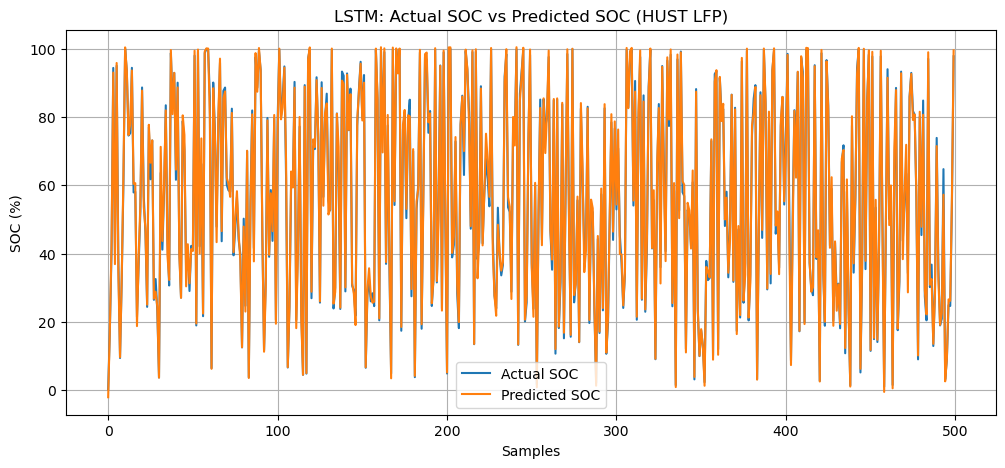

In [38]:
import matplotlib.pyplot as plt

# Inverse transform if target was scaled
y_test_inv = target_scaler.inverse_transform(y_test)
lstm_pred_inv = target_scaler.inverse_transform(lstm_pred)

plt.figure(figsize=(12,5))

plt.plot(y_test_inv[:500], label='Actual SOC')
plt.plot(lstm_pred_inv[:500], label='Predicted SOC')

plt.title('LSTM: Actual SOC vs Predicted SOC (HUST LFP)')
plt.xlabel('Samples')
plt.ylabel('SOC (%)')
plt.legend()
plt.grid(True)

plt.show()

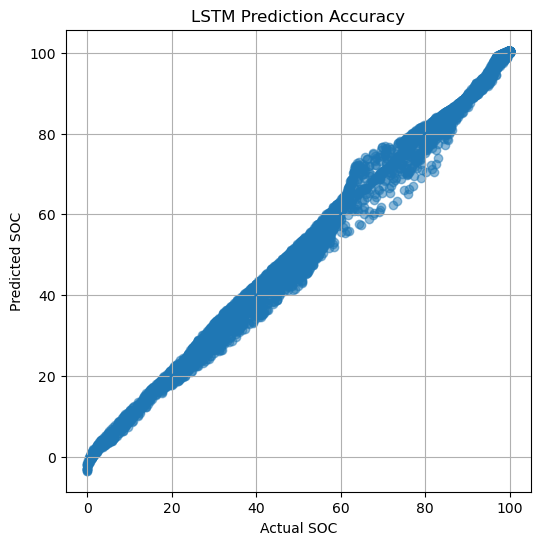

In [39]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test_inv[:5000],
    lstm_pred_inv[:5000],
    alpha=0.5
)

plt.xlabel("Actual SOC")
plt.ylabel("Predicted SOC")
plt.title("LSTM Prediction Accuracy")

plt.plot(
    [y_test_inv.min(), y_test_inv.max()],
    [y_test_inv.min(), y_test_inv.max()]
)

plt.grid(True)
plt.show()

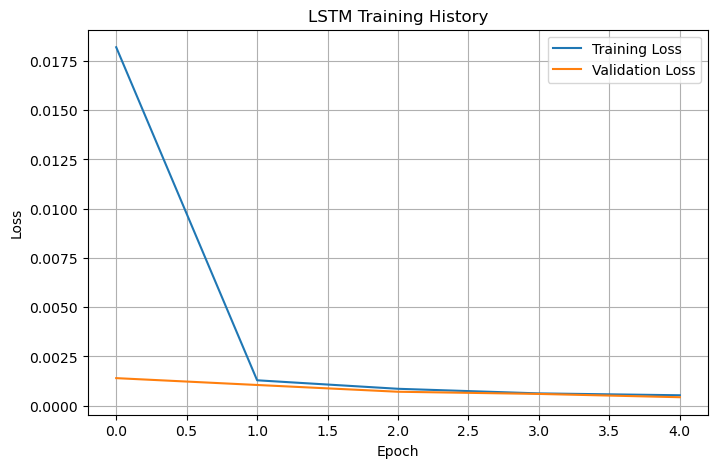

In [40]:
plt.figure(figsize=(8,5))

plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')

plt.title('LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

### GRU

In [37]:
# GRU Training
gru_model = Sequential([
    GRU(32, input_shape=(20, 3)),
    Dense(16, activation='relu'),
    Dense(1)
])

gru_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

C:\Users\shrij\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - loss: 0.0287 - mae: 0.0913 - val_loss: 0.0017 - val_mae: 0.0320
Epoch 2/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0016 - mae: 0.0298 - val_loss: 0.0014 - val_mae: 0.0278
Epoch 3/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0014 - mae: 0.0280 - val_loss: 0.0012 - val_mae: 0.0258
Epoch 4/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0011 - mae: 0.0250 - val_loss: 9.0869e-04 - val_mae: 0.0235
Epoch 5/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 7.7612e-04 - mae: 0.0211 - val_loss: 6.6524e-04 - val_mae: 0.0206


In [41]:
# GRU Metrics
gru_loss, gru_mae = gru_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

gru_pred = gru_model.predict(X_test)

gru_rmse = np.sqrt(
    mean_squared_error(y_test, gru_pred)
)

print("GRU Results")
print("Loss :", gru_loss)
print("MAE  :", gru_mae)
print("RMSE :", gru_rmse)

625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
GRU Results
Loss : 0.0006712900358252227
MAE  : 0.02070428431034088
RMSE : 0.025909260777815447


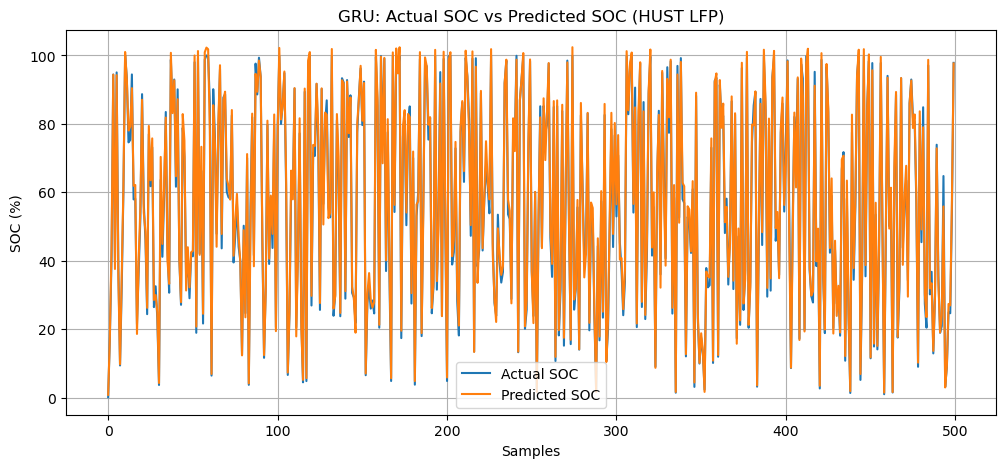

In [42]:
y_test_inv = target_scaler.inverse_transform(y_test)
gru_pred_inv = target_scaler.inverse_transform(gru_pred)

plt.figure(figsize=(12,5))

plt.plot(y_test_inv[:500], label='Actual SOC')
plt.plot(gru_pred_inv[:500], label='Predicted SOC')

plt.title('GRU: Actual SOC vs Predicted SOC (HUST LFP)')
plt.xlabel('Samples')
plt.ylabel('SOC (%)')
plt.legend()
plt.grid(True)

plt.show()

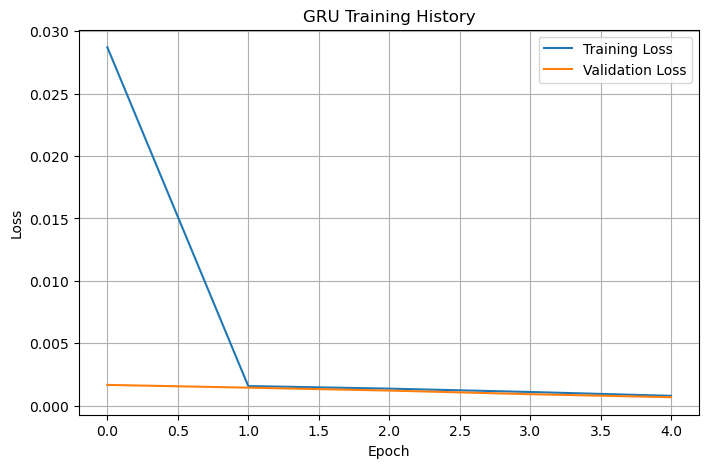

In [43]:
plt.figure(figsize=(8,5))

plt.plot(history_gru.history['loss'],
         label='Training Loss')

plt.plot(history_gru.history['val_loss'],
         label='Validation Loss')

plt.title('GRU Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

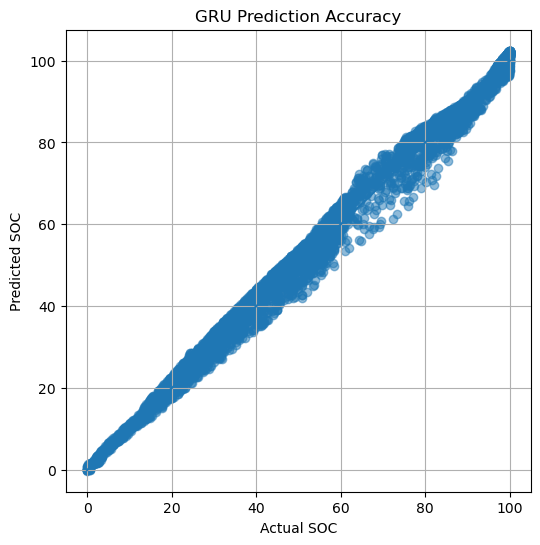

In [44]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test_inv[:5000],
    gru_pred_inv[:5000],
    alpha=0.5
)

plt.plot(
    [y_test_inv.min(), y_test_inv.max()],
    [y_test_inv.min(), y_test_inv.max()]
)

plt.xlabel('Actual SOC')
plt.ylabel('Predicted SOC')
plt.title('GRU Prediction Accuracy')

plt.grid(True)
plt.show()

## Summary and Discussion

The HUST Battery Dataset, representing Lithium Iron Phosphate (LFP) chemistry, was utilized to develop and evaluate deep learning models for State of Charge (SOC) estimation. More than 1.16 million data samples collected across hundreds of battery cycles were processed and transformed into sequential time-series data suitable for recurrent neural networks.

A subset of 100,000 representative sequences was selected to reduce computational complexity while preserving the dynamic charging behaviour of the battery. Voltage, Current, and Capacity were used as input features, while SOC was calculated from the available capacity information and used as the target variable.

Two deep learning architectures, Long Short-Term Memory (LSTM) and Gated Recurrent Unit (GRU), were trained and evaluated for SOC prediction.

### Results

| Model | Loss     | MAE     | RMSE    |
| ----- | -------- | ------- | ------- |
| LSTM  | 0.000452 | 0.01543 | 0.02127 |
| GRU   | 0.000671 | 0.02070 | 0.02591 |

The LSTM model achieved the lowest prediction error across all evaluation metrics, demonstrating its superior ability to capture the long-term temporal dependencies present in LFP battery behaviour. The predicted SOC closely followed the actual SOC trajectory, indicating effective learning of the battery charging characteristics.

An interesting observation emerged when comparing results with the previously analyzed LG HG2 (NCA) dataset. While the GRU model performed better on the NCA chemistry, the LSTM model achieved superior performance on the HUST LFP dataset. This suggests that the effectiveness of recurrent neural network architectures may vary across battery chemistries due to differences in electrochemical behaviour and voltage-capacity characteristics.

Overall, the results demonstrate that deep learning techniques can accurately estimate battery SOC and that model performance is influenced not only by architecture choice but also by the underlying battery chemistry. The HUST dataset provided a robust benchmark for evaluating SOC estimation under LFP battery conditions, with LSTM emerging as the preferred model for this dataset.
